Nome: Maria Eduarda Rezende Rodrigues
RA: 165873

In [19]:
# imports
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [20]:
# inicialização das variáveis utilizadas no código
# Variáveis parte 3
x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
n = list(range(5))

pi = math.pi

data = {
    "Aproximação por truncamento": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Aproximação por arredondamento": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Erro absoluto": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Erro relativo": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Erro percentual": {3.14159265: [], 98.76543: [], 0.00498765: []}
}

df = pd.DataFrame(data)

plt.style.use("seaborn-v0_8-whitegrid")

# Variáveis parte 4
pressao_sist = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

In [21]:
# função para calcular erro absoluto, relativo ou percentual
def calc_erro(valor_referencia, valor_aproximado, tipo_erro):
    if tipo_erro == 'abs':
        erro = abs(valor_referencia - valor_aproximado)
    elif tipo_erro == 'rel':
        erro = abs((valor_referencia - valor_aproximado) / valor_referencia)
    elif tipo_erro == 'percent':
        erro = abs((valor_referencia - valor_aproximado) / valor_referencia) * 100
    else:
        print("Erro inválido. Opções -> abs, rel, percent")
    
    return erro

# função para truncar sem arredondar
def trunc(x, n):
    return math.trunc((10 ** n) * x) / (10 ** n)

Aproximação por truncamento (x1): 3.0, 3.1, 3.14, 3.141, 3.1415
Aproximação por truncamento (x2): 98.0, 98.7, 98.76, 98.765, 98.7654
Aproximação por truncamento (x3): 0.0, 0.0, 0.0, 0.004, 0.0049
Aproximação por arredondamento (x1): 3.0, 3.1, 3.14, 3.142, 3.1416
Aproximação por arredondamento (x2): 99.0, 98.8, 98.77, 98.765, 98.7654
Aproximação por arredondamento (x3): 0.0, 0.0, 0.0, 0.005, 0.005
Erro para x1 (truncamento):
  abs      = [0.1415926500000002, 0.04159265000000012, 0.0015926500000000843, 0.0005926500000001944, 9.265000000002743e-05]
  rel      = [0.04507034035746175, 0.013239351702710444, 0.000506956240809923, 0.0001886463542624453, 2.949141098863579e-05]
  percent  = [4.507034035746175, 1.3239351702710445, 0.050695624080992305, 0.01886463542624453, 0.002949141098863579]
Erro para x1 (arredondamento):
  abs      = [0.1415926500000002, 0.04159265000000012, 0.0015926500000000843, 0.00040734999999969546, 7.349999999739509e-06]
  rel      = [0.04507034035746175, 0.013239351702

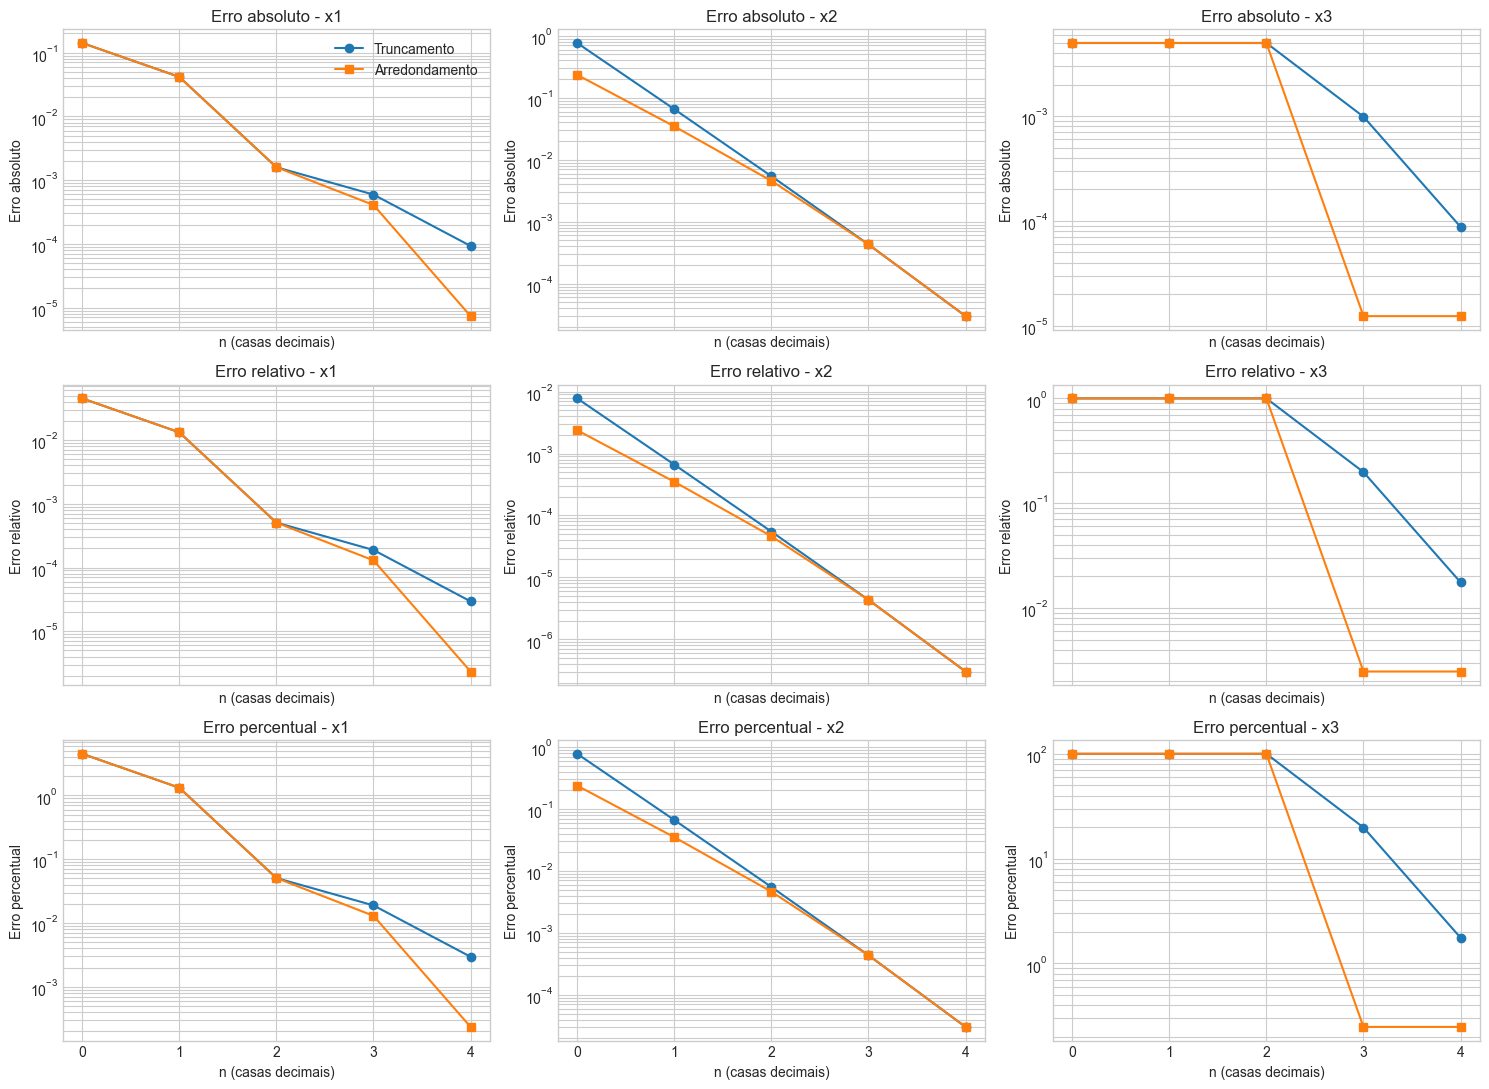

In [22]:
# 3.1
for nome, valor in [("x1", x1), ("x2", x2), ("x3", x3)]:
    aproximacoes = [trunc(valor, casa_decimal) for casa_decimal in n]
    print(
        f"Aproximação por truncamento ({nome}): "
        + ", ".join(map(str, aproximacoes))
    )
    df.at[valor, "Aproximação por truncamento"] = aproximacoes


for nome, valor in [("x1", x1), ("x2", x2), ("x3", x3)]:
    aproximacoes = [round(valor, casa_decimal) for casa_decimal in n]
    print(
        f"Aproximação por arredondamento ({nome}): "
        + ", ".join(map(str, aproximacoes))
    )
    df.at[valor, "Aproximação por arredondamento"] = aproximacoes

# 3.2
for nome, valor_referencia in [("x1", x1), ("x2", x2), ("x3", x3)]:
    trunc_abs = [
        calc_erro(valor_referencia, trunc(valor_referencia, casa), "abs")
        for casa in n
    ]
    trunc_rel = [
        calc_erro(valor_referencia, trunc(valor_referencia, casa), "rel")
        for casa in n
    ]
    trunc_percent = [
        calc_erro(valor_referencia, trunc(valor_referencia, casa), "percent")
        for casa in n
    ]

    arred_abs = [
        calc_erro(valor_referencia, round(valor_referencia, casa), "abs")
        for casa in n
    ]
    arred_rel = [
        calc_erro(valor_referencia, round(valor_referencia, casa), "rel")
        for casa in n
    ]
    arred_percent = [
        calc_erro(valor_referencia, round(valor_referencia, casa), "percent")
        for casa in n
    ]

    print(f"Erro para {nome} (truncamento):")
    print(f"  abs      = {trunc_abs}")
    print(f"  rel      = {trunc_rel}")
    print(f"  percent  = {trunc_percent}")

    print(f"Erro para {nome} (arredondamento):")
    print(f"  abs      = {arred_abs}")
    print(f"  rel      = {arred_rel}")
    print(f"  percent  = {arred_percent}")

    df.at[valor_referencia, "Erro absoluto"] = {
        "truncamento": trunc_abs,
        "arredondamento": arred_abs,
    }
    df.at[valor_referencia, "Erro relativo"] = {
        "truncamento": trunc_rel,
        "arredondamento": arred_rel,
    }
    df.at[valor_referencia, "Erro percentual"] = {
        "truncamento": trunc_percent,
        "arredondamento": arred_percent,
    }

# 3.3
print(df)

# 3.4 e 3.5
valores = [x1, x2, x3]
nomes = ["x1", "x2", "x3"]
tipos_erro = [
    ("abs", "Erro absoluto"),
    ("rel", "Erro relativo"),
    ("percent", "Erro percentual"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)

for linha, (tipo, titulo) in enumerate(tipos_erro):
    for coluna, (nome, valor) in enumerate(zip(nomes, valores)):
        erro_trunc = [
            calc_erro(valor, trunc(valor, casas), tipo)
            for casas in n
        ]
        erro_arred = [
            calc_erro(valor, round(valor, casas), tipo)
            for casas in n
        ]

        ax = axes[linha, coluna]
        ax.semilogy(n, erro_trunc, marker="o", label="Truncamento")
        ax.semilogy(n, erro_arred, marker="s", label="Arredondamento")

        ax.set_title(f"{titulo} - {nome}")
        ax.set_xticks(n)
        ax.set_xlabel("n (casas decimais)")
        ax.set_ylabel(titulo)
        ax.grid(True, which="both")

        if linha == 0 and coluna == 0:
            ax.legend()

plt.tight_layout()
plt.show()


In [23]:
# 4.1.1
pressao_sist_arrednd = []
pressao_sist_trunc = []

print(f"Dados originais: {pressao_sist}")

# 4.1.2
for x in pressao_sist:
    y = round(x)
    pressao_sist_arrednd.append(y)
print(f"Dados arredondados: {pressao_sist_arrednd}")

# 4.1.3
for x in pressao_sist:
    y = trunc(x, 1)
    pressao_sist_trunc.append(y)
print(f"Dados truncados: {pressao_sist_trunc}")



Dados originais: [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
Dados arredondados: [122, 120, 122, 120, 121, 121, 122, 121, 120, 122]
Dados truncados: [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]


In [24]:
# 4.1
def estatisticas(serie):
    """Calcula média, mínimo, máximo, amplitude e desvio-padrão amostral de uma série."""
    serie = np.array(serie, dtype=float)
    return {
        "média (mmHg)": np.mean(serie),
        "mínimo (mmHg)": np.min(serie),
        "máximo (mmHg)": np.max(serie),
        "amplitude (mmHg)": np.max(serie) - np.min(serie),
        "desvio-padrão amostral (mmHg)": np.std(serie, ddof=1),
    }

# média de referência: média calculada com todos os algarismos disponíveis (dados originais)
media_referencia = np.mean(pressao_sist)

series_pressao = {
    "Original": pressao_sist,
    "Arredondada (inteiro)": pressao_sist_arrednd,
    "Truncada": pressao_sist_trunc,
}

df_estatisticas = pd.DataFrame({nome: estatisticas(serie) for nome, serie in series_pressao.items()}).T
df_estatisticas.index.name = "Série"
print("Estatísticas das séries de pressão sistólica (mmHg):")
display(df_estatisticas)

# erros da média aproximada em relação à média de referência
erros_media = {}
for nome, serie in series_pressao.items():
    if nome == "Original":
        continue
    media_aprox = np.mean(serie)
    erros_media[nome] = {
        "média aproximada (mmHg)": media_aprox,
        "Erro absoluto (mmHg)": calc_erro(media_referencia, media_aprox, "abs"),
        "Erro relativo": calc_erro(media_referencia, media_aprox, "rel"),
        "Erro percentual (%)": calc_erro(media_referencia, media_aprox, "percent"),
    }

df_erros_media = pd.DataFrame(erros_media).T
df_erros_media.index.name = "Série"
print(f"\nMédia de referência (todos os algarismos): {media_referencia:.4f} mmHg\n")
print("Erros da média aproximada em relação à média de referência:")
display(df_erros_media)

Estatísticas das séries de pressão sistólica (mmHg):


,média (mmHg),mínimo (mmHg),máximo (mmHg),amplitude (mmHg),desvio-padrão amostral (mmHg)
Série,,,,,
Original,121.12,119.8,122.4,2.6,0.833733
Arredondada (inteiro),121.10,120.0,122.0,2.0,0.875595
Truncada,121.12,119.8,122.4,2.6,0.833733



Média de referência (todos os algarismos): 121.1200 mmHg

Erros da média aproximada em relação à média de referência:


,média aproximada (mmHg),Erro absoluto (mmHg),Erro relativo,Erro percentual (%)
Série,,,,
Arredondada (inteiro),121.10,0.02,0.000165,0.016513
Truncada,121.12,0.00,0.000000,0.000000


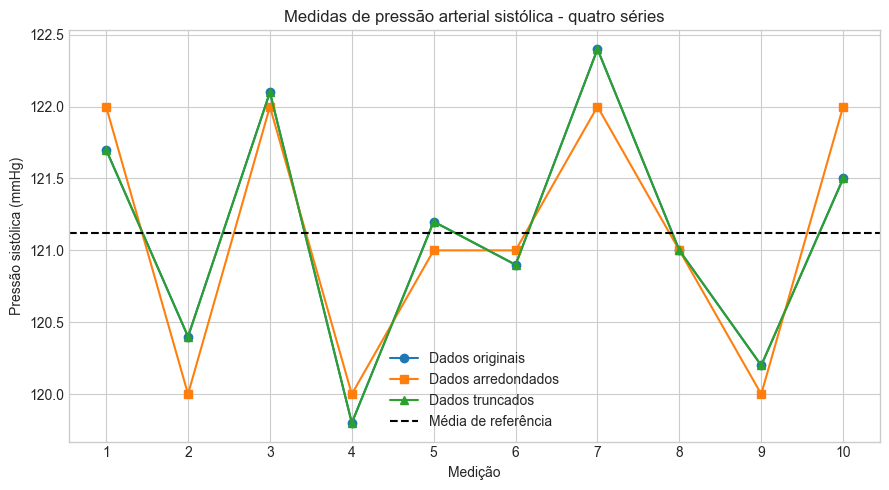

In [25]:
# 4.2.1
medicoes = list(range(1, len(pressao_sist) + 1))

plt.figure(figsize=(9, 5))
plt.plot(medicoes, pressao_sist, marker="o", label="Dados originais")
plt.plot(medicoes, pressao_sist_arrednd, marker="s", label="Dados arredondados")
plt.plot(medicoes, pressao_sist_trunc, marker="^", label="Dados truncados")
plt.axhline(media_referencia, color="black", linestyle="--", label="Média de referência")
plt.xlabel("Medição")
plt.ylabel("Pressão sistólica (mmHg)")
plt.title("Medidas de pressão arterial sistólica - quatro séries")
plt.xticks(medicoes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

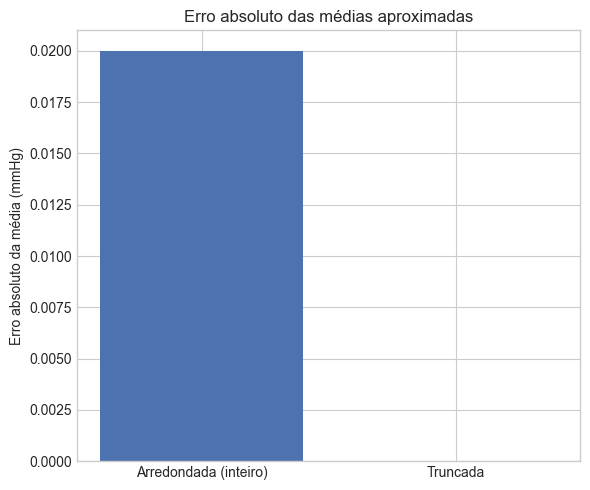

In [26]:
# 4.2.2
plt.figure(figsize=(6, 5))
plt.bar(df_erros_media.index, df_erros_media["Erro absoluto (mmHg)"], color=["#4C72B0", "#DD8452"])
plt.ylabel("Erro absoluto da média (mmHg)")
plt.title("Erro absoluto das médias aproximadas")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

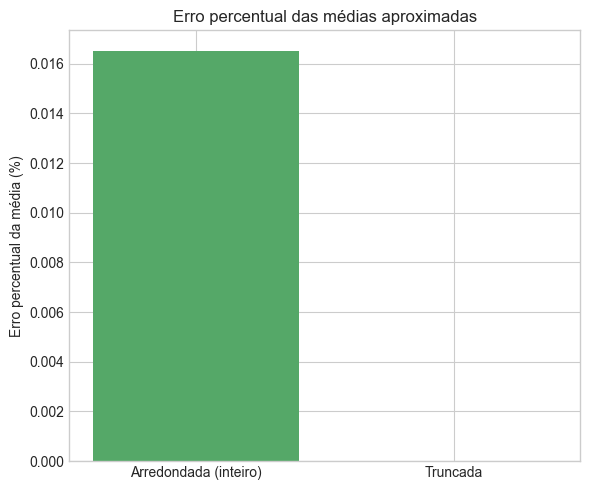

In [27]:
# 4.2.3
plt.figure(figsize=(6, 5))
plt.bar(df_erros_media.index, df_erros_media["Erro percentual (%)"], color=["#55A868", "#C44E52"])
plt.ylabel("Erro percentual da média (%)")
plt.title("Erro percentual das médias aproximadas")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

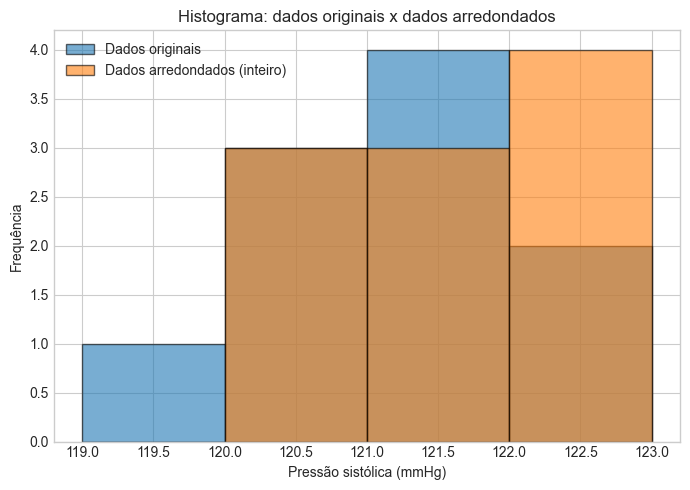

In [28]:
# 4.2.4
plt.figure(figsize=(7, 5))
bins = np.arange(min(pressao_sist_arrednd) - 1, max(pressao_sist_arrednd) + 2, 1)
plt.hist(pressao_sist, bins=bins, alpha=0.6, label="Dados originais", edgecolor="black")
plt.hist(pressao_sist_arrednd, bins=bins, alpha=0.6, label="Dados arredondados (inteiro)", edgecolor="black")
plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Frequência")
plt.title("Histograma: dados originais x dados arredondados")
plt.legend()
plt.tight_layout()
plt.show()

**Discussão (Parte B):** os erros absoluto e percentual da média arredondada em inteiros ficam abaixo de meio mmHg e abaixo de aproximadamente 0,3%, ou seja, a média é bem preservada pela representação inteira. Já a **variabilidade** é afetada de forma mais visível: o desvio-padrão amostral e a amplitude calculados a partir dos dados arredondados/truncados diferem dos valores originais, porque o passo de 1 mmHg do arredondamento é da mesma ordem de grandeza da dispersão natural desta amostra pequena (poucas dezenas de mmHg de variação). Assim, para reportar a *tendência central* (a média), a representação inteira é praticamente suficiente; para descrever a *dispersão* da amostra com fidelidade, ela introduz uma distorção que não deve ser ignorada.

In [29]:
# função comentada para a vazão de Hagen-Poiseuille
def vazao_hagen_poiseuille(r, dp, mu, L):
    """Calcula a vazão volumétrica Q (m^3/s) pela equação de Hagen-Poiseuille.

    Parâmetros (todos em unidades SI):
        r  -- raio do tubo (m)
        dp -- diferença de pressão (Pa)
        mu -- viscosidade dinâmica (Pa.s)
        L  -- comprimento do tubo (m)
    """
    return (math.pi * r**4 * dp) / (8 * mu * L)

# valores de referência da Parte C, já convertidos para unidades SI
r_C = 0.80e-3      # m  (0,80 mm)
L_C = 0.20          # m
mu_C = 3.5e-3       # Pa.s
dp_C = 1200.0       # Pa

Q_ref_C = vazao_hagen_poiseuille(r_C, dp_C, mu_C, L_C)
print(f"Q de referência (Parte C): {Q_ref_C:.6e} m^3/s")

Q de referência (Parte C): 2.757421e-07 m^3/s


In [30]:
# C.1
r_mm = r_C * 1e3   # raio em mm, para arredondar/truncar com 1 casa decimal

r_arred_mm = round(r_mm, 1)
r_trunc_mm = trunc(r_mm, 1)
mu_arred = round(mu_C, 3)
mu_trunc = trunc(mu_C, 3)
dp_arred = round(dp_C, -2)
dp_trunc = trunc(dp_C, -2)

cenarios = {
    "1. Todos os valores fornecidos": (r_C, dp_C, mu_C),
    "2a. r arredondado (1 casa, mm)": (r_arred_mm * 1e-3, dp_C, mu_C),
    "2b. r truncado (1 casa, mm)": (r_trunc_mm * 1e-3, dp_C, mu_C),
    "3a. µ arredondada (3 casas)": (r_C, dp_C, mu_arred),
    "3b. µ truncada (3 casas)": (r_C, dp_C, mu_trunc),
    "4a. ∆p arredondada (centena)": (r_C, dp_arred, mu_C),
    "4b. ∆p truncada (centena)": (r_C, dp_trunc, mu_C),
    "5a. Todas arredondadas": (r_arred_mm * 1e-3, dp_arred, mu_arred),
    "5b. Todas truncadas": (r_trunc_mm * 1e-3, dp_trunc, mu_trunc),
}

linhas_C1 = []
for nome, (r_i, dp_i, mu_i) in cenarios.items():
    Q_i = vazao_hagen_poiseuille(r_i, dp_i, mu_i, L_C)
    linhas_C1.append({
        "Cenário": nome,
        "r (m)": r_i,
        "∆p (Pa)": dp_i,
        "µ (Pa.s)": mu_i,
        "Q (m³/s)": Q_i,
        "Erro absoluto (m³/s)": calc_erro(Q_ref_C, Q_i, "abs"),
        "Erro relativo": calc_erro(Q_ref_C, Q_i, "rel"),
        "Erro percentual (%)": calc_erro(Q_ref_C, Q_i, "percent"),
    })

df_C1 = pd.DataFrame(linhas_C1).set_index("Cenário")
display(df_C1)

,r (m),∆p (Pa),µ (Pa.s),Q (m³/s),Erro absoluto (m³/s),Erro relativo,Erro percentual (%)
Cenário,,,,,,,
1. Todos os valores fornecidos,0.0008,1200.0,0.0035,2.757421e-07,0.000000e+00,0.000000,0.000000
"2a. r arredondado (1 casa, mm)",0.0008,1200.0,0.0035,2.757421e-07,0.000000e+00,0.000000,0.000000
"2b. r truncado (1 casa, mm)",0.0008,1200.0,0.0035,2.757421e-07,0.000000e+00,0.000000,0.000000
3a. µ arredondada (3 casas),0.0008,1200.0,0.0040,2.412743e-07,3.446776e-08,0.125000,12.500000
3b. µ truncada (3 casas),0.0008,1200.0,0.0030,3.216991e-07,4.595701e-08,0.166667,16.666667
4a. ∆p arredondada (centena),0.0008,1200.0,0.0035,2.757421e-07,0.000000e+00,0.000000,0.000000
4b. ∆p truncada (centena),0.0008,1200.0,0.0035,2.757421e-07,0.000000e+00,0.000000,0.000000
5a. Todas arredondadas,0.0008,1200.0,0.0040,2.412743e-07,3.446776e-08,0.125000,12.500000
5b. Todas truncadas,0.0008,1200.0,0.0030,3.216991e-07,4.595701e-08,0.166667,16.666667


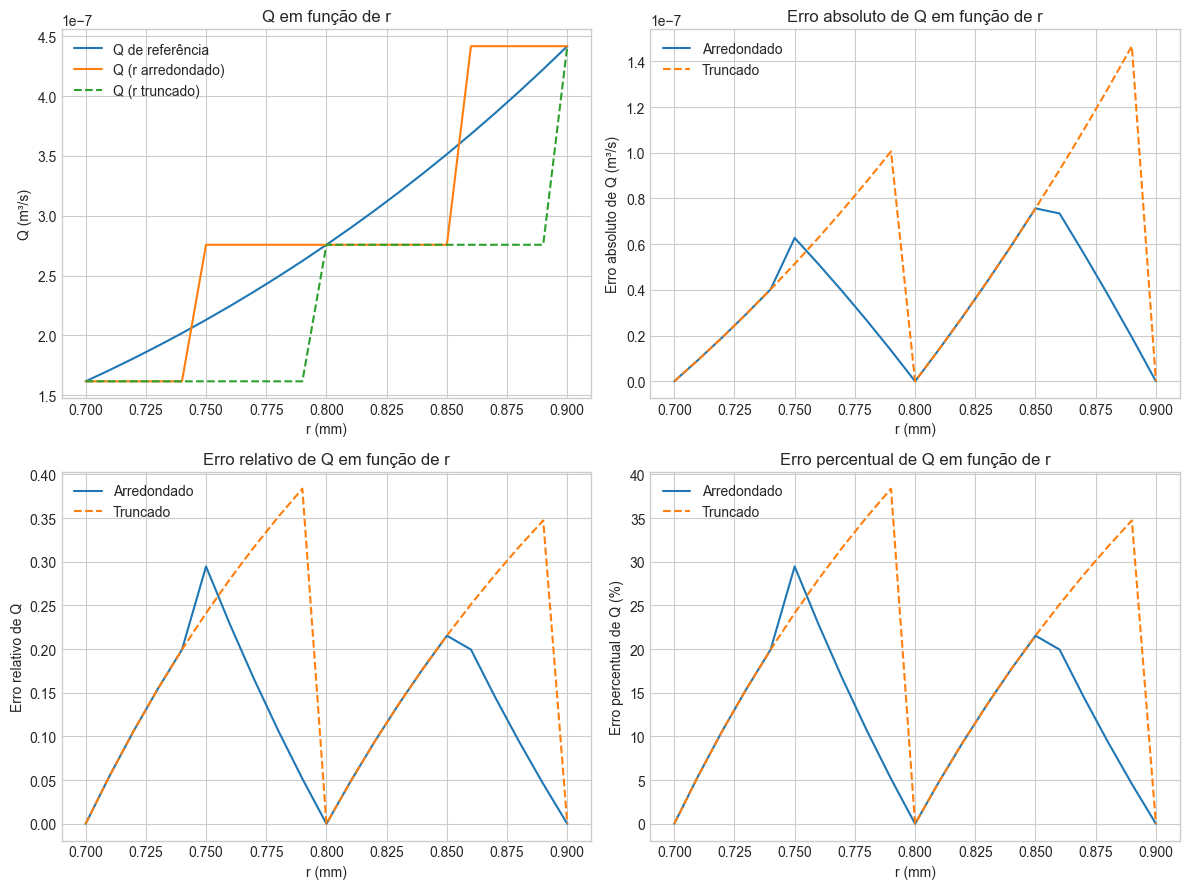

In [31]:
# C.2
r_vals_mm = np.arange(0.70, 0.90 + 1e-9, 0.01)   # mm
r_vals_m = r_vals_mm * 1e-3

Q_referencia_r = np.array([vazao_hagen_poiseuille(r, dp_C, mu_C, L_C) for r in r_vals_m])
r_arred_vals_m = np.array([round(r_mm_i, 1) for r_mm_i in r_vals_mm]) * 1e-3
r_trunc_vals_m = np.array([trunc(r_mm_i, 1) for r_mm_i in r_vals_mm]) * 1e-3

Q_arred_r = np.array([vazao_hagen_poiseuille(r, dp_C, mu_C, L_C) for r in r_arred_vals_m])
Q_trunc_r = np.array([vazao_hagen_poiseuille(r, dp_C, mu_C, L_C) for r in r_trunc_vals_m])

erro_abs_arred = np.array([calc_erro(qr, qa, "abs") for qr, qa in zip(Q_referencia_r, Q_arred_r)])
erro_abs_trunc = np.array([calc_erro(qr, qt, "abs") for qr, qt in zip(Q_referencia_r, Q_trunc_r)])
erro_rel_arred = np.array([calc_erro(qr, qa, "rel") for qr, qa in zip(Q_referencia_r, Q_arred_r)])
erro_rel_trunc = np.array([calc_erro(qr, qt, "rel") for qr, qt in zip(Q_referencia_r, Q_trunc_r)])
erro_pct_arred = np.array([calc_erro(qr, qa, "percent") for qr, qa in zip(Q_referencia_r, Q_arred_r)])
erro_pct_trunc = np.array([calc_erro(qr, qt, "percent") for qr, qt in zip(Q_referencia_r, Q_trunc_r)])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(r_vals_mm, Q_referencia_r, label="Q de referência")
axes[0, 0].plot(r_vals_mm, Q_arred_r, label="Q (r arredondado)")
axes[0, 0].plot(r_vals_mm, Q_trunc_r, label="Q (r truncado)", linestyle="--")
axes[0, 0].set_xlabel("r (mm)")
axes[0, 0].set_ylabel("Q (m³/s)")
axes[0, 0].set_title("Q em função de r")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(r_vals_mm, erro_abs_arred, label="Arredondado")
axes[0, 1].plot(r_vals_mm, erro_abs_trunc, label="Truncado", linestyle="--")
axes[0, 1].set_xlabel("r (mm)")
axes[0, 1].set_ylabel("Erro absoluto de Q (m³/s)")
axes[0, 1].set_title("Erro absoluto de Q em função de r")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(r_vals_mm, erro_rel_arred, label="Arredondado")
axes[1, 0].plot(r_vals_mm, erro_rel_trunc, label="Truncado", linestyle="--")
axes[1, 0].set_xlabel("r (mm)")
axes[1, 0].set_ylabel("Erro relativo de Q")
axes[1, 0].set_title("Erro relativo de Q em função de r")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(r_vals_mm, erro_pct_arred, label="Arredondado")
axes[1, 1].plot(r_vals_mm, erro_pct_trunc, label="Truncado", linestyle="--")
axes[1, 1].set_xlabel("r (mm)")
axes[1, 1].set_ylabel("Erro percentual de Q (%)")
axes[1, 1].set_title("Erro percentual de Q em função de r")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

**Discussão (Parte C):** como $Q \\propto r^4$, um pequeno erro relativo no raio é amplificado aproximadamente 4 vezes no erro relativo da vazão ($\\Delta Q / Q \\approx 4\\,\\Delta r / r$). Isso é visível nos gráficos: mesmo arredondando/truncando o raio para apenas 1 casa decimal em mm, os erros absoluto, relativo e percentual de Q são bem maiores do que o erro relativo introduzido diretamente no raio. O expoente 4 é o principal responsável por essa amplificação — quanto maior o expoente, mais sensível a grandeza final é a pequenas variações da variável de entrada.

In [32]:
# valores de referência da Parte D (nanocateter), em unidades SI
r_D = 50e-9      # m  (50 nm)
L_D = 10e-6       # m  (10 µm)
mu_D = 3.5e-3     # Pa.s
dp_D = 5000.0     # Pa

Q_ref_D = vazao_hagen_poiseuille(r_D, dp_D, mu_D, L_D)
print(f"Q de referência (nanocateter): {Q_ref_D:.6e} m^3/s")

Q de referência (nanocateter): 3.506242e-19 m^3/s


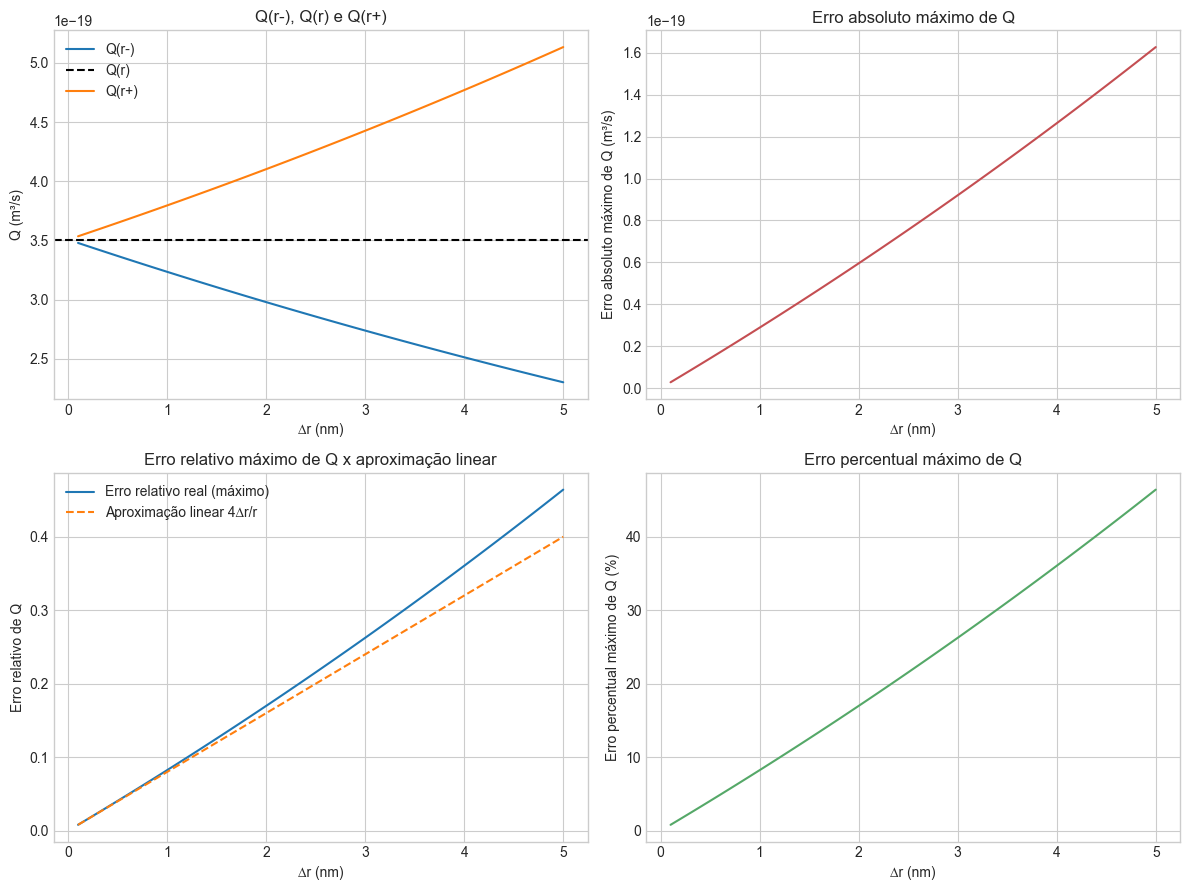

In [33]:
# D.1
delta_r_nm = np.arange(0.1, 5.0 + 1e-9, 0.1)   # nm
delta_r_m = delta_r_nm * 1e-9

r_minus = r_D - delta_r_m
r_plus = r_D + delta_r_m

Q_minus = np.array([vazao_hagen_poiseuille(r, dp_D, mu_D, L_D) for r in r_minus])
Q_plus = np.array([vazao_hagen_poiseuille(r, dp_D, mu_D, L_D) for r in r_plus])

erro_abs_minus = np.array([calc_erro(Q_ref_D, q, "abs") for q in Q_minus])
erro_abs_plus = np.array([calc_erro(Q_ref_D, q, "abs") for q in Q_plus])
erro_abs_max = np.maximum(erro_abs_minus, erro_abs_plus)

erro_rel_minus = np.array([calc_erro(Q_ref_D, q, "rel") for q in Q_minus])
erro_rel_plus = np.array([calc_erro(Q_ref_D, q, "rel") for q in Q_plus])
erro_rel_max = np.maximum(erro_rel_minus, erro_rel_plus)

erro_pct_minus = np.array([calc_erro(Q_ref_D, q, "percent") for q in Q_minus])
erro_pct_plus = np.array([calc_erro(Q_ref_D, q, "percent") for q in Q_plus])
erro_pct_max = np.maximum(erro_pct_minus, erro_pct_plus)

# aproximação linear: delta_Q / Q ~= 4 * delta_r / r
aprox_linear_rel = 4 * delta_r_m / r_D

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(delta_r_nm, Q_minus, label="Q(r-)")
axes[0, 0].axhline(Q_ref_D, color="black", linestyle="--", label="Q(r)")
axes[0, 0].plot(delta_r_nm, Q_plus, label="Q(r+)")
axes[0, 0].set_xlabel("∆r (nm)")
axes[0, 0].set_ylabel("Q (m³/s)")
axes[0, 0].set_title("Q(r-), Q(r) e Q(r+)")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(delta_r_nm, erro_abs_max, color="#C44E52")
axes[0, 1].set_xlabel("∆r (nm)")
axes[0, 1].set_ylabel("Erro absoluto máximo de Q (m³/s)")
axes[0, 1].set_title("Erro absoluto máximo de Q")
axes[0, 1].grid(True)

axes[1, 0].plot(delta_r_nm, erro_rel_max, label="Erro relativo real (máximo)")
axes[1, 0].plot(delta_r_nm, aprox_linear_rel, label="Aproximação linear 4∆r/r", linestyle="--")
axes[1, 0].set_xlabel("∆r (nm)")
axes[1, 0].set_ylabel("Erro relativo de Q")
axes[1, 0].set_title("Erro relativo máximo de Q x aproximação linear")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(delta_r_nm, erro_pct_max, color="#55A868")
axes[1, 1].set_xlabel("∆r (nm)")
axes[1, 1].set_ylabel("Erro percentual máximo de Q (%)")
axes[1, 1].set_title("Erro percentual máximo de Q")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

A aproximação linear $\\Delta Q/Q \\approx 4\\,\\Delta r/r$ acompanha bem o erro relativo real para $\\Delta r$ pequeno, e a diferença entre as duas curvas cresce ligeiramente conforme $\\Delta r$ aumenta (efeito dos termos de ordem superior desprezados na linearização). No nanocateter, como $r$ é da ordem de dezenas de nanômetros, um $\\Delta r$ de poucos nanômetros já representa uma fração significativa de $r$, e o expoente 4 amplifica fortemente esse erro na vazão.

### D.2 — Precisão computacional (float32 x float64)

In [34]:
# D.2
r32 = np.float32(r_D)
r64 = np.float64(r_D)
dp32 = np.float32(dp_D)
dp64 = np.float64(dp_D)
mu32 = np.float32(mu_D)
mu64 = np.float64(mu_D)
L32 = np.float32(L_D)
L64 = np.float64(L_D)

r4_32 = r32 ** np.float32(4)
r4_64 = r64 ** np.float64(4)

Q_32 = (np.float32(math.pi) * r4_32 * dp32) / (np.float32(8) * mu32 * L32)
Q_64 = (np.float64(math.pi) * r4_64 * dp64) / (np.float64(8) * mu64 * L64)

diff_abs = abs(float(Q_64) - float(Q_32))
diff_rel = diff_abs / abs(float(Q_64))

print(f"r^4 (float32): {r4_32}")
print(f"r^4 (float64): {r4_64}")
print(f"Q (float32): {Q_32:.10e} m^3/s")
print(f"Q (float64): {Q_64:.10e} m^3/s")
print(f"Diferença absoluta entre Q32 e Q64: {diff_abs:.3e} m^3/s")
print(f"Diferença relativa entre Q32 e Q64: {diff_rel:.3e}")
print(f"eps (float32): {np.finfo(np.float32).eps}")
print(f"eps (float64): {np.finfo(np.float64).eps}")

r^4 (float32): 6.2500003959774226e-30
r^4 (float64): 6.249999999999999e-30
Q (float32): 3.5062423237e-19 m^3/s
Q (float64): 3.5062418009e-19 m^3/s
Diferença absoluta entre Q32 e Q64: 5.229e-26 m^3/s
Diferença relativa entre Q32 e Q64: 1.491e-07
eps (float32): 1.1920928955078125e-07
eps (float64): 2.220446049250313e-16


In [35]:
# comparação entre delta1 (cálculo direto) e delta2 (expansão), para Delta_r/r decrescente
razoes = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
linhas_D2 = []
for razao in razoes:
    dr = razao * r_D
    delta1 = vazao_hagen_poiseuille(r_D + dr, dp_D, mu_D, L_D) - vazao_hagen_poiseuille(r_D, dp_D, mu_D, L_D)
    delta2 = vazao_hagen_poiseuille(r_D, dp_D, mu_D, L_D) * ((1 + dr / r_D) ** 4 - 1)
    linhas_D2.append({
        "∆r/r": razao,
        "δ1 = Q(r+∆r) - Q(r)  (m³/s)": delta1,
        "δ2 = Q(r)[(1+∆r/r)^4 - 1]  (m³/s)": delta2,
        "|δ1 - δ2|  (m³/s)": abs(delta1 - delta2),
    })

df_D2 = pd.DataFrame(linhas_D2)
display(df_D2)

,∆r/r,δ1 = Q(r+∆r) - Q(r) (m³/s),δ2 = Q(r)[(1+∆r/r)^4 - 1] (m³/s),|δ1 - δ2| (m³/s)
0,1.000000e-01,1.627247e-19,1.627247e-19,2.888895e-34
1,1.000000e-02,1.423675e-20,1.423675e-20,1.263892e-34
2,1.000000e-03,1.404602e-21,1.404602e-21,7.842898e-35
3,1.000000e-04,1.402707e-22,1.402707e-22,4.560918e-36
4,1.000000e-05,1.402518e-23,1.402518e-23,1.757217e-34
5,1.000000e-06,1.402499e-24,1.402499e-24,9.155411e-35
6,1.000000e-07,1.402497e-25,1.402497e-25,1.617354e-34
7,1.000000e-08,1.402497e-26,1.402497e-26,6.315597e-35


Para razões $\\Delta r / r$ muito pequenas (a partir de $10^{-6}$–$10^{-7}$), $\\delta_1$ e $\\delta_2$ passam a divergir de forma perceptível: $\\delta_1$ subtrai dois números muito próximos em ponto flutuante, o que causa **perda de significância por cancelamento catastrófico**, enquanto $\\delta_2$, por manter a variação relativa dentro da potência antes de subtrair 1, preserva mais dígitos significativos e é numericamente mais estável nesse regime.

### D.3 — Fenômeno físico

Ao reduzir a escala do tubo de milímetros (Parte C) para nanômetros (nanocateter, Parte D), a razão entre a área da superfície interna e o volume do canal aumenta muito: enquanto o volume escala com $r^2 L$, a área lateral escala com $rL$, de modo que a razão superfície/volume cresce como $1/r$. Isso significa que, em escalas nanométricas, os efeitos de parede (atrito viscoso, condições de não-deslizamento, interações moleculares fluido-parede) passam a dominar o escoamento, algo que a equação de Hagen–Poiseuille — derivada para um contínuo macroscópico — não captura adequadamente. Por isso, um resultado de vazão obtido com muitas casas decimais (como os calculados acima em float64) pode ser numericamente preciso e, ainda assim, **fisicamente inadequado**: precisão aritmética e validade do modelo físico são conceitos distintos, e no regime de nanocateteres a segunda passa a ser a principal limitação.

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/quadro_resultados.png'

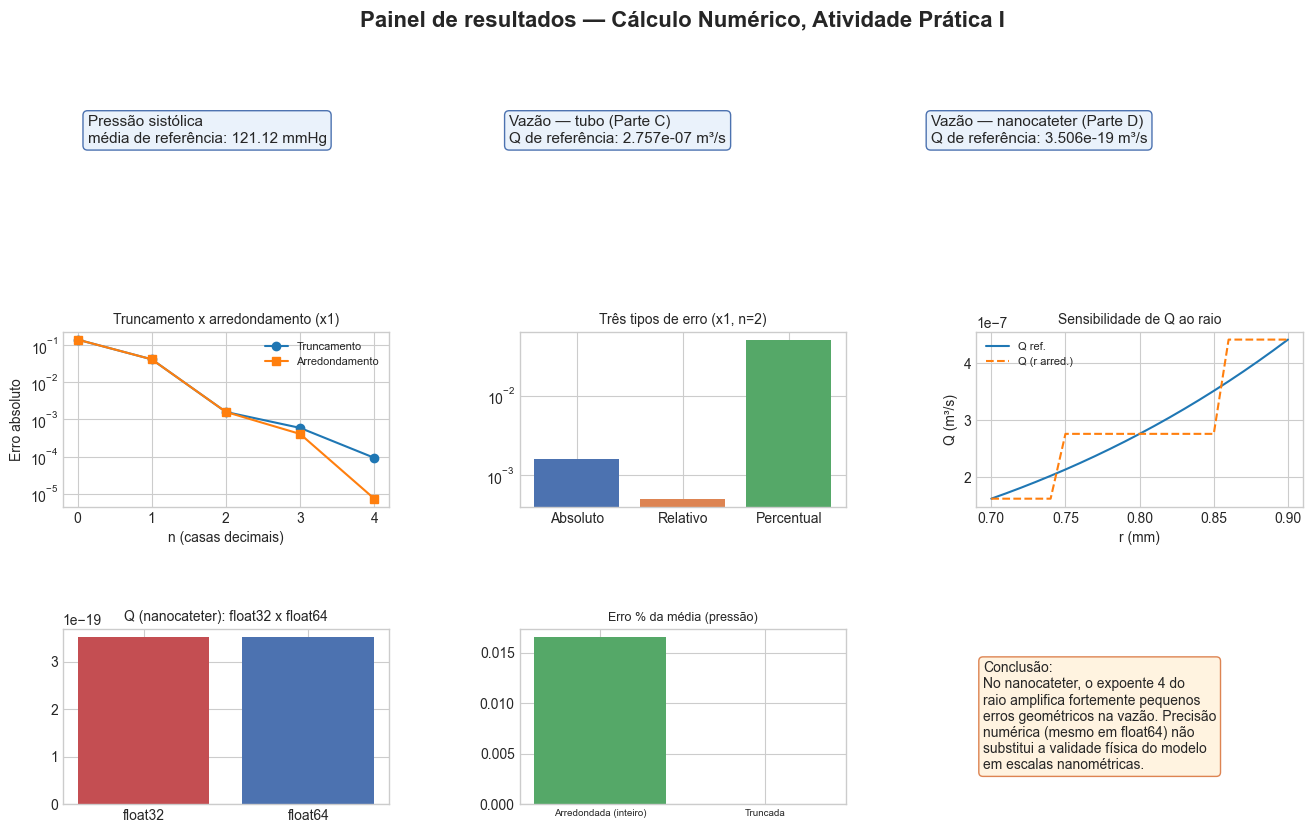

In [36]:
# Parte E - quadro único de resultados em PNG (>= 1600x1000 pixels)
fig = plt.figure(figsize=(16, 10), dpi=100)   # 16 pol x 10 pol a 100 dpi = 1600x1000 px
gs = fig.add_gridspec(3, 3, hspace=0.7, wspace=0.4)

# cartões com os principais valores de pressão e vazão
ax_cards = fig.add_subplot(gs[0, :])
ax_cards.axis("off")
ax_cards.set_title("Painel de resultados — Cálculo Numérico, Atividade Prática I", fontsize=16, fontweight="bold")
cartoes = [
    f"Pressão sistólica\nmédia de referência: {media_referencia:.2f} mmHg",
    f"Vazão — tubo (Parte C)\nQ de referência: {Q_ref_C:.3e} m³/s",
    f"Vazão — nanocateter (Parte D)\nQ de referência: {Q_ref_D:.3e} m³/s",
]
for i, texto in enumerate(cartoes):
    ax_cards.text(0.02 + i * 0.34, 0.45, texto, fontsize=11, va="center",
                  bbox=dict(boxstyle="round", facecolor="#EAF2FB", edgecolor="#4C72B0"))
ax_cards.set_xlim(0, 1)
ax_cards.set_ylim(0, 1)

# comparação truncamento x arredondamento (x1)
ax1 = fig.add_subplot(gs[1, 0])
erro_trunc_x1 = [calc_erro(x1, trunc(x1, c), "abs") for c in n]
erro_arred_x1 = [calc_erro(x1, round(x1, c), "abs") for c in n]
ax1.semilogy(n, erro_trunc_x1, marker="o", label="Truncamento")
ax1.semilogy(n, erro_arred_x1, marker="s", label="Arredondamento")
ax1.set_title("Truncamento x arredondamento (x1)", fontsize=10)
ax1.set_xlabel("n (casas decimais)")
ax1.set_ylabel("Erro absoluto")
ax1.legend(fontsize=8)
ax1.grid(True)

# os três tipos de erro (x1, n=2)
ax2 = fig.add_subplot(gs[1, 1])
tipos = ["abs", "rel", "percent"]
valores_erro = [calc_erro(x1, round(x1, 2), t) for t in tipos]
ax2.bar(["Absoluto", "Relativo", "Percentual"], valores_erro,
        color=["#4C72B0", "#DD8452", "#55A868"])
ax2.set_yscale("log")
ax2.set_title("Três tipos de erro (x1, n=2)", fontsize=10)

# sensibilidade de Q ao raio (tubo)
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(r_vals_mm, Q_referencia_r, label="Q ref.")
ax3.plot(r_vals_mm, Q_arred_r, label="Q (r arred.)", linestyle="--")
ax3.set_xlabel("r (mm)")
ax3.set_ylabel("Q (m³/s)")
ax3.set_title("Sensibilidade de Q ao raio", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True)

# float32 x float64
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(["float32", "float64"], [float(Q_32), float(Q_64)], color=["#C44E52", "#4C72B0"])
ax4.set_title("Q (nanocateter): float32 x float64", fontsize=10)
ax4.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# erro percentual das médias de pressão (Parte B)
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(df_erros_media.index, df_erros_media["Erro percentual (%)"],
        color=["#55A868", "#C44E52"])
ax5.set_title("Erro % da média (pressão)", fontsize=9)
ax5.tick_params(axis="x", labelsize=7)

# conclusão curta sobre o nanocateter
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
conclusao = (
    "Conclusão:\nNo nanocateter, o expoente 4 do\n"
    "raio amplifica fortemente pequenos\n"
    "erros geométricos na vazão. Precisão\n"
    "numérica (mesmo em float64) não\n"
    "substitui a validade física do modelo\n"
    "em escalas nanométricas."
)
ax6.text(0.02, 0.5, conclusao, fontsize=10, va="center",
         bbox=dict(boxstyle="round", facecolor="#FFF3E0", edgecolor="#DD8452"))

fig.savefig("/mnt/user-data/outputs/quadro_resultados.png", dpi=100)
plt.show()
print("PNG salvo em /mnt/user-data/outputs/quadro_resultados.png (1600x1000 pixels)")

In [ ]:
# GIF demonstrativo: raio do nanocateter variando de 45 a 55 nm (40 quadros)
import io
import os
from PIL import Image

os.makedirs("/mnt/user-data/outputs", exist_ok=True)

raios_gif_nm = np.linspace(45, 55, 40)   # 40 quadros, entre 30 e 60 exigidos
Q_referencia_gif = vazao_hagen_poiseuille(50e-9, dp_D, mu_D, L_D)  # referência: r = 50 nm

Q_min_eixo = vazao_hagen_poiseuille(45e-9, dp_D, mu_D, L_D) * 0.9
Q_max_eixo = vazao_hagen_poiseuille(55e-9, dp_D, mu_D, L_D) * 1.1

Q_progressivo = []
frames = []

for idx, r_nm in enumerate(raios_gif_nm):
    r_m = r_nm * 1e-9
    Q_atual = vazao_hagen_poiseuille(r_m, dp_D, mu_D, L_D)
    Q_progressivo.append(Q_atual)
    erro_pct_atual = calc_erro(Q_referencia_gif, Q_atual, "percent")

    fig_gif, axes_gif = plt.subplots(1, 2, figsize=(9, 4))

    # seção transversal do canal
    circulo = plt.Circle((0, 0), r_nm, color="#4C72B0", alpha=0.6)
    axes_gif[0].add_patch(circulo)
    axes_gif[0].set_xlim(-30, 30)
    axes_gif[0].set_ylim(-30, 30)
    axes_gif[0].set_aspect("equal")
    axes_gif[0].set_title(
        f"r = {r_nm:.2f} nm\nQ = {Q_atual:.3e} m³/s\nErro % vs r=50nm: {erro_pct_atual:.2f}%",
        fontsize=9,
    )
    axes_gif[0].set_xlabel("nm")
    axes_gif[0].set_ylabel("nm")

    # curva Q x r sendo construída progressivamente
    axes_gif[1].plot(raios_gif_nm[: idx + 1], Q_progressivo, color="#DD8452")
    axes_gif[1].set_xlim(45, 55)
    axes_gif[1].set_ylim(Q_min_eixo, Q_max_eixo)
    axes_gif[1].set_xlabel("r (nm)")
    axes_gif[1].set_ylabel("Q (m³/s)")
    axes_gif[1].set_title("Curva Q x r (progressiva)")

    plt.tight_layout()

    buf = io.BytesIO()
    fig_gif.savefig(buf, format="png", dpi=100)
    plt.close(fig_gif)
    buf.seek(0)
    frames.append(Image.open(buf).convert("RGB"))

caminho_gif = "/mnt/user-data/outputs/nanocateter_variacao_raio.gif"
frames[0].save(
    caminho_gif,
    save_all=True,
    append_images=frames[1:],
    duration=120,
    loop=0,
)
print(f"GIF salvo em: {caminho_gif} ({len(frames)} quadros)")